# Distinguishing stylometric signals for authorship and for speech versus narrative

Our goal in this study is to explore the way that speech is distinguished from narrative across a number of authors, spanning hundreds of years of Greek epic. We're inspired by [Burns (2025) "Measuring Dialogism in Latin Epic"](https://doi.org/10.1163/9789004750227_010) but before replicating Burns' methods we're going to use a generic bag of most common features to confirm that speech and narrative look different in this corpus, and some sense of how that difference might relate to what we predict will be a clear authorship signal.

## Preliminaries

### Import statements

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import ccc2026

### Setup

Use package-level helper method to download the token data. Pre-parsed tokens for Homers' *Iliad* and *Odyssey*, Apollonius' *Argonautica*, Quintus' *Posthomerica*, Triphiodorus' *Sack of Troy*, and Nonnus' *Dionysiaca* are downloaded from our [Open Science Framework archive](https://osf.io/yahps). For more details on the parsing pipeline, see https://github.com/cwf2/uva_common.

In [2]:
# set force_download=True to clobber local data
ccc2026.setup()

### Global values

See `src/ccc2026/config.py`.

In [3]:
# local directory structure
tokens_dir = os.path.join(ccc2026.CONFIG["data_dir"], "tokens")
plot_dir = ccc2026.CONFIG["plot_dir"]

# token files to process
token_files = [filename for _, filename in ccc2026.CONFIG["texts"]]

# Initialize random number generator
seed = 1
rng = np.random.default_rng(seed)

### Load tokens

In [4]:
# concatenate all per-text token tables into one corpus-wide frame
tokens = pd.concat(
    [pd.read_csv(os.path.join(tokens_dir, filename), dtype=str) for filename in token_files],
    ignore_index=True,
)

print(f"Loaded {len(tokens)} tokens from {len(token_files)} texts.")

Loaded 429774 tokens from 6 texts.


### Select most frequent lemmas

In [5]:
# corpus-wide count for all non-punctuation lemmas, from most frequent to least
corpus_lemma_count = tokens["lemma"].value_counts()

# a list of the top lemmas
top_lemmas = corpus_lemma_count.head(100).index

# show results
display(corpus_lemma_count.loc[top_lemmas])

lemma
δέ        21339
καί       13671
ὁ          9589
τε         5574
ἐγώ        3783
          ...  
τίθημι      530
πέλω        530
ἄγω         525
σύν         520
βαίνω       519
Name: count, Length: 100, dtype: int64

### Labels

Label each token by work title and by speech/narrative. We're allowing *Iliad* and *Odyssey* to be by different authors.

In [6]:
# Narratological groups
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

# default group is "other"
nara_group_ids = pd.Series("oth", index=tokens.index)
nara_group_ids[nr_mask] = "nar"
nara_group_ids[sp_mask] = "spk"

# Authorship groups
auth_group_ids = tokens["work"].str.slice(0,4)

# Combined two-factor group
group_ids = auth_group_ids + "-" + nara_group_ids

## Authorship

In this experiment, we're using samples defined just by the books of the epics. Some issues include very unequal sample sizes and non-randomized sampling of tokens. On the other hand, it gives a better sense of the internal heterogeneity of the poems and matches meaningful real-world units of text.

### Define samples

In [7]:
# sample labels are just work title + book number
tokens["sample_id"] = tokens["work"] + " " + tokens["line_id"].str.split("_", expand=True).iloc[:,0]

In [8]:
display(tokens)

,author,title,work,urn,line_id,text,lemma,pos,verbform,mood,...,gender,speech_id,speaker,addressee,level,type,cluster,turn,tags,sample_id
0,Homer,Ἰλιάς,Iliad,urn:cts:greekLit:tlg0012.tlg001.perseus-grc2:1.1,01_0001,μῆνιν,μῆνις,NOUN,NaN,NaN,...,Fem,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Iliad 01
1,Homer,Ἰλιάς,Iliad,urn:cts:greekLit:tlg0012.tlg001.perseus-grc2:1.1,01_0001,ἄειδε,ἀείδω,VERB,Fin,Ind,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Iliad 01
2,Homer,Ἰλιάς,Iliad,urn:cts:greekLit:tlg0012.tlg001.perseus-grc2:1.1,01_0001,θεὰ,θεά,NOUN,NaN,NaN,...,Fem,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Iliad 01
3,Homer,Ἰλιάς,Iliad,urn:cts:greekLit:tlg0012.tlg001.perseus-grc2:1.1,01_0001,Πηληϊάδεω,πηλείδης,NOUN,NaN,NaN,...,Masc,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Iliad 01
4,Homer,Ἰλιάς,Iliad,urn:cts:greekLit:tlg0012.tlg001.perseus-grc2:1.1,01_0001,Ἀχιλῆος,ἀχιλλεύς,NOUN,NaN,NaN,...,Masc,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Iliad 01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429769,Nonnus of Panopolis,Διονυσιακά,Dionysiaca,urn:cts:greekLit:tlg2045.tlg001.perseus-grc2:4...,48_0978,σύνθρονος,σύνθρονος,ADJ,NaN,NaN,...,Masc,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Dionysiaca 48
429770,Nonnus of Panopolis,Διονυσιακά,Dionysiaca,urn:cts:greekLit:tlg2045.tlg001.perseus-grc2:4...,48_0978,Ἀπόλλωνι,ἀπόλλων,NOUN,NaN,NaN,...,Masc,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Dionysiaca 48
429771,Nonnus of Panopolis,Διονυσιακά,Dionysiaca,urn:cts:greekLit:tlg2045.tlg001.perseus-grc2:4...,48_0978,συνέστιος,συνέστιος,ADJ,NaN,NaN,...,Masc,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Dionysiaca 48
429772,Nonnus of Panopolis,Διονυσιακά,Dionysiaca,urn:cts:greekLit:tlg2045.tlg001.perseus-grc2:4...,48_0978,υἱέι,υἱέι,NOUN,NaN,NaN,...,Masc,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Dionysiaca 48


### Tokens per sample

Distribution of book lengths in tokens. This is just to give me a sense of how diverse our samples are. The longest are the four books of Apollonius' *Argonautica*.

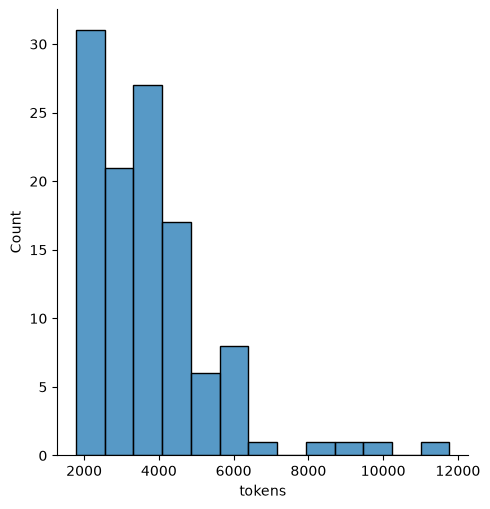

In [9]:
tokens_per_sample = tokens.groupby("sample_id").size()
g = sns.displot(tokens_per_sample)
g.set_xlabels("tokens")
plt.show()

### Generate feature vectors by book

In [10]:
# tally lemma counts
samples = pd.crosstab(
    tokens.loc[tokens["lemma"].isin(top_lemmas), "sample_id"],
    tokens.loc[tokens["lemma"].isin(top_lemmas), "lemma"],
)

# normalize as freq / 1000 words
samples = samples.div(tokens_per_sample, axis=0) * 1000

display(samples)

lemma,Διόνυσος,αἱρέω,αὐτός,βάλλω,βαίνω,γάρ,γαῖα,γε,δέ,δή,...,ἵστημι,ὀδυσσεύς,ὁ,ὄφρα,ὅδε,ὅς,ὅσος,ὅτε,ὑπό,ὡς
sample_id,,,,,,,,,,,,,,,,,,,,,
Argonautica 01,0.111595,1.339136,7.365249,1.450731,2.008704,6.137708,2.566678,1.673920,52.895882,4.240598,...,0.669568,0.000000,29.126214,2.231894,1.785515,7.030465,2.343488,2.678273,2.901462,7.142060
Argonautica 02,0.000000,1.412263,8.002825,1.647640,0.941509,6.708250,3.883724,1.412263,54.725197,5.295987,...,1.059197,0.000000,29.422149,0.706132,3.177592,6.590561,2.706838,2.471461,3.766035,7.179004
Argonautica 03,0.000000,1.564619,10.013560,1.251695,1.251695,5.006780,2.086158,2.503390,57.369354,4.172317,...,0.625848,0.000000,27.850214,1.356003,3.755085,5.736935,1.668927,2.712006,3.233545,9.492020
Argonautica 04,0.084926,1.273885,5.859873,2.208068,1.358811,6.539278,3.397028,1.358811,52.314225,5.265393,...,0.339703,0.000000,26.581741,1.953291,3.397028,8.067941,1.868365,2.717622,2.802548,6.878981
Dionysiaca 01,0.619195,0.000000,2.476780,0.619195,0.928793,3.715170,1.547988,0.928793,40.557276,0.309598,...,1.547988,0.000000,5.263158,1.857585,0.309598,0.928793,0.309598,1.857585,2.167183,4.953560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Posthomerica 11,0.000000,2.644725,5.583309,5.877167,0.293858,7.052601,2.350867,0.881575,67.881281,2.938584,...,0.587717,0.881575,25.859536,1.175433,0.000000,6.464884,0.881575,2.644725,8.228034,7.640317
Posthomerica 12,0.000000,0.247770,4.212091,1.486620,1.734390,10.158573,1.734390,1.486620,64.172448,2.477701,...,0.991080,0.743310,23.785927,1.982161,0.247770,5.450942,2.477701,2.725471,6.689792,10.158573
Posthomerica 13,0.000000,0.773595,6.704487,2.320784,0.773595,6.188757,1.289324,1.289324,57.246003,2.836514,...,0.257865,0.515730,28.623002,0.773595,0.257865,7.220217,2.320784,1.289324,6.704487,10.830325


### Dimensionality reduction

In [11]:
model = PCA(n_components=3)
scaled = StandardScaler().fit_transform(samples)
pca = pd.DataFrame(model.fit_transform(scaled), columns=["PC1", "PC2", "PC3"])

## Author signal
### plot individual books

This plot shows how the different books cluster themselves according to author/work based on the most frequent words.


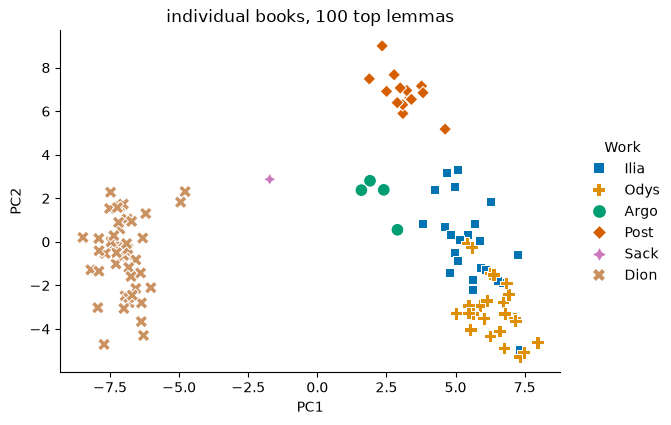

In [12]:
# Labels for legend: take first 4 chars of index (e.g. "Iliad" -> "Ilia")
short_label = samples.index.str.slice(0,4)

# Custom order for labels in the legend (top to bottom)
label_order = ["Ilia", "Odys", "Argo", "Post", "Sack", "Dion"]

# Plot using Seaborn
g = sns.relplot(data=pca,
    x = "PC1",
    y = "PC2",
    s = 84,
    hue = short_label,        # color points by work
    hue_order = label_order,
    style = short_label,
    palette = "colorblind",         # seaborn color palette; try "muted", "bright", "colorblind", etc.
)

# Figure dimensions in inches (width, height)
g.figure.set_size_inches(7, 4)

# Set figure title
g.ax.set_title(f"individual books, {len(samples.columns)} top lemmas")

# Set legend heading
g._legend.set_title("Work")

# Export figure as png file
g.savefig(os.path.join(plot_dir, "auth_PCA_by_book.png"),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Speech vs. Narrative

This part shows the speech/narrative signal by averaging out authorship. We randomly sample 1000 tokens at a time from the corpus as a whole, according only to whether they are narrative or speech.

### Create new samples

In [13]:
# create samples
sample_size = 1000
for group in nara_group_ids.unique():
    n_toks = sum(nara_group_ids==group)
    tokens.loc[nara_group_ids==group, "sample_id"] = (rng.permutation(n_toks) // sample_size).astype(str)
tokens["sample_id"] = nara_group_ids + "-" + tokens["sample_id"].map(str)

### Tokens per sample

Unlike the plot of sample size distribution above, this should show almost all samples having the same number of tokens.

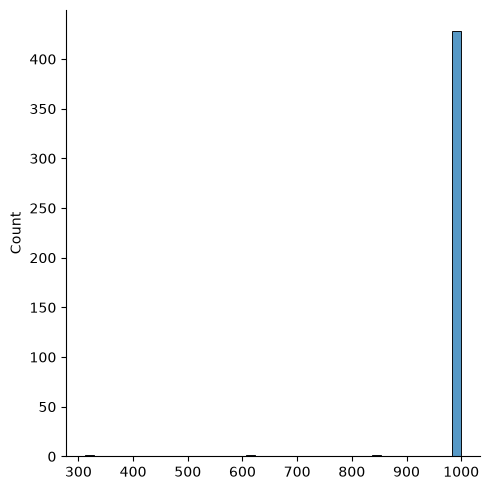

In [14]:
tokens_per_sample = tokens.groupby("sample_id").size()
sns.displot(tokens_per_sample)

### Remove any stub samples

In [15]:
# samples with fewer than `sample_size` tokens
stub_list = tokens_per_sample[tokens_per_sample < sample_size]
# set sample id to NaN to drop from aggregation
tokens.loc[tokens["sample_id"].isin(stub_list.index), "sample_id"] = np.nan

### Calculate feature vectors for each sample

As in the author signal plot above, we're using the same top 100 words.

In [16]:
# tally lemma counts
samples = pd.crosstab(
    tokens.loc[tokens["lemma"].isin(top_lemmas), "sample_id"],
    tokens.loc[tokens["lemma"].isin(top_lemmas), "lemma"],
)

# normalize as freq / 1000 words
samples = samples.div(sample_size, axis=0) * 1000

display(samples)

lemma,Διόνυσος,αἱρέω,αὐτός,βάλλω,βαίνω,γάρ,γαῖα,γε,δέ,δή,...,ἵστημι,ὀδυσσεύς,ὁ,ὄφρα,ὅδε,ὅς,ὅσος,ὅτε,ὑπό,ὡς
sample_id,,,,,,,,,,,,,,,,,,,,,
nar-0,3.0,2.0,6.0,2.0,1.0,6.0,3.0,0.0,48.0,4.0,...,2.0,2.0,30.0,0.0,1.0,4.0,2.0,4.0,4.0,10.0
nar-1,1.0,4.0,6.0,2.0,0.0,4.0,3.0,0.0,66.0,3.0,...,1.0,5.0,30.0,1.0,0.0,10.0,2.0,4.0,3.0,6.0
nar-10,2.0,4.0,4.0,1.0,4.0,4.0,3.0,2.0,66.0,4.0,...,2.0,1.0,24.0,0.0,0.0,9.0,0.0,0.0,4.0,9.0
nar-100,2.0,0.0,5.0,2.0,1.0,3.0,2.0,5.0,63.0,1.0,...,2.0,2.0,34.0,0.0,0.0,9.0,1.0,3.0,5.0,11.0
nar-101,1.0,1.0,4.0,3.0,1.0,8.0,2.0,0.0,76.0,1.0,...,1.0,0.0,27.0,2.0,0.0,5.0,1.0,3.0,0.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
spk-95,0.0,0.0,6.0,1.0,1.0,14.0,2.0,4.0,34.0,4.0,...,0.0,1.0,10.0,3.0,5.0,12.0,2.0,3.0,0.0,5.0
spk-96,1.0,0.0,4.0,1.0,0.0,11.0,0.0,9.0,27.0,3.0,...,2.0,3.0,11.0,2.0,8.0,8.0,6.0,3.0,1.0,4.0
spk-97,2.0,1.0,2.0,2.0,0.0,10.0,2.0,6.0,37.0,3.0,...,1.0,0.0,9.0,3.0,3.0,5.0,0.0,4.0,2.0,4.0


### Dimensionality reduction

In [17]:
model = PCA(n_components=3)
scaled = StandardScaler().fit_transform(samples)
pca = pd.DataFrame(model.fit_transform(scaled), columns=["PC1", "PC2", "PC3"])

### Plot

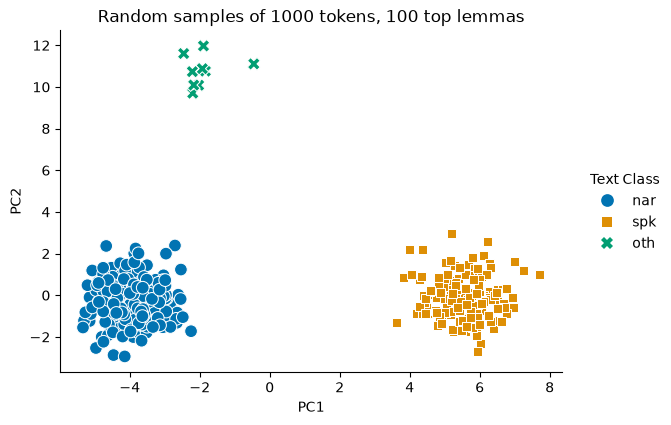

In [18]:
# Labels for legend: take first 3 chars of index
short_label = samples.index.str.slice(0,3)

# Custom order for labels in the legend (top to bottom)
label_order = ["nar", "spk", "oth"]

# Plot using Seaborn
g = sns.relplot(data=pca,
    x = "PC1",
    y = "PC2",
    s = 84,
    hue = short_label,
    hue_order = label_order,
    style = short_label,
    palette = "colorblind", 
)

# Figure dimensions in inches (width, height)
g.figure.set_size_inches(7, 4)

# Set figure title
g.ax.set_title(f"Random samples of {sample_size} tokens, {len(samples.columns)} top lemmas")

# Set legend heading
g._legend.set_title("Text Class")

# Export figure as png file
g.savefig(os.path.join(plot_dir, "spk-nar_PCA_by_book.png"),
    dpi = 300,
    bbox_inches = "tight",
)

plt.show()

## Speech-like words per author

For each work × class (e.g. `Ilia-spk`, `Ilia-nar`), we compute the relative frequency of each of the top 100 lemmas (per 1000 words), then z-score across the 100 lemmas within each profile (`axis=1`). This rescales each profile so it reflects which lemmas are over- or under-represented relative to that profile's own overall lemma distribution.

Taking the difference (spk − nar) for each author then highlights lemmas whose *relative* prominence shifts between speech and narrative, which is what the ranked tables below show.

In [19]:
# calculate frequencies
freq = pd.crosstab(group_ids, tokens["lemma"], normalize="index") * 1000

# remove apologue
freq = freq.loc[~(freq.index=="Odys-oth"), top_lemmas]

# calculate z-scores
scaled = pd.DataFrame(zscore(freq, axis=1), index=freq.index, columns=freq.columns)

# take difference between spk and nar for each author
mask = scaled.index.str.endswith("spk")
masked_names = scaled[mask].index.str.slice(0,4)
assert masked_names.equals(scaled[~mask].index.str.slice(0,4))

diff_scaled = scaled[mask].reset_index(drop=True) - scaled[~mask].reset_index(drop=True)
diff_scaled.index = masked_names
diff_scaled.index.name = "work"
display(diff_scaled)

lemma,δέ,καί,ὁ,τε,ἐγώ,ἐν,ὡς,εἰμί,σύ,μέν,...,αἱρέω,ὅσος,σφεῖς,κόρη,οὗτος,τίθημι,πέλω,ἄγω,σύν,βαίνω
work,,,,,,,,,,,,,,,,,,,,,
Argo,-2.766589,1.443437,-0.932954,0.606813,3.567194,-0.039144,-0.617463,1.157666,2.299845,0.115008,...,-0.274765,-0.033516,-0.569715,-0.160396,-0.151500,-0.220005,-0.027261,-0.203836,-0.223836,-0.401645
Dion,-2.652491,0.094459,-0.575987,-0.403523,2.284084,0.074167,-0.257422,0.217288,3.160989,-0.404624,...,-0.212478,-0.100182,-0.153697,-0.296309,0.366929,-0.203025,0.045887,-0.111491,-0.095048,-0.133233
Ilia,-2.741234,2.269896,-1.727743,0.240564,3.447846,0.171920,-1.003522,1.650842,2.835900,0.238574,...,-0.293483,-0.119786,-0.374067,-0.261797,0.142946,-0.341143,-0.261812,-0.177182,-0.264485,-0.595425
Odys,-3.113208,2.359726,-1.975026,1.060428,3.517642,0.628704,-0.879895,1.701871,2.835580,0.422412,...,-0.484806,-0.146495,-0.361426,-0.405314,0.222297,-0.518657,-0.323109,-0.188751,-0.259044,-0.702302
Post,-3.835346,2.324262,-1.914859,0.149876,3.969219,0.359352,-0.617101,1.686959,2.906771,-0.046243,...,-0.321856,-0.101145,-0.503880,-0.253455,-0.178607,-0.066874,0.259405,-0.146986,-0.310762,-0.342383
Sack,-2.691506,1.874779,-2.710639,-0.934477,2.851526,-0.049188,-0.164834,0.323802,3.382433,-0.076572,...,0.152860,-0.174138,-0.174138,-0.295367,0.193270,-0.174138,-0.174138,-0.089597,0.031632,-0.214548


#### Table of top words per author, for export

This table gives a ranked list of speech-like words for each author, along with z-score difference for each.

In [20]:
def show_top_lemmas_per_work(n=10, show_scores=False):
    '''Generate a table of top speech/narrative lemmas'''
    
    works = ["Ilia", "Odys", "Argo", "Post", "Sack", "Dion"]

    if show_scores:
        return pd.DataFrame(
            {work: [f"{lem} ({val:.2f})"
            for lem, val in diff_scaled.loc[work].sort_values(ascending=False).head(n).items()]
                 for work in works},
            index=range(1, n + 1)
        )
    else:
        return pd.DataFrame(
            {work: diff_scaled.loc[work].sort_values(ascending=False).head(n).index
                 for work in works},
            index=range(1, n + 1)
        )

show_top_lemmas_per_work(show_scores=True)

,Ilia,Odys,Argo,Post,Sack,Dion
1,ἐγώ (3.45),ἐγώ (3.52),ἐγώ (3.57),ἐγώ (3.97),σύ (3.38),σύ (3.16)
2,σύ (2.84),σύ (2.84),σύ (2.30),σύ (2.91),ἐγώ (2.85),ἐγώ (2.28)
3,καί (2.27),καί (2.36),ἄν (1.49),καί (2.32),καί (1.87),οὐ (2.07)
4,εἰμί (1.65),εἰμί (1.70),καί (1.44),εἰμί (1.69),γάρ (1.14),ἐμός (1.40)
5,ἄν (1.47),τίς (1.68),εἰ (1.36),γάρ (1.50),εἰ (1.01),μή (0.97)
6,τίς (1.15),οὐ (1.33),εἰμί (1.16),ἀλλά (1.38),ἀλλά (0.97),εἰ (0.87)
7,οὐ (1.12),ἄν (1.19),τίς (1.13),νῦν (1.33),ἔτι (0.89),τίς (0.78)
8,ἀλλά (1.06),ἀλλά (1.16),οὐ (0.86),οὐ (1.33),τίς (0.69),γάρ (0.77)
9,νῦν (0.95),τε (1.06),ὅδε (0.82),τίς (0.92),οὐδέ (0.61),ἀλλά (0.62)
10,γάρ (0.90),γάρ (1.01),νῦν (0.76),εἰ (0.44),ἐπί (0.54),οὗτος (0.37)
